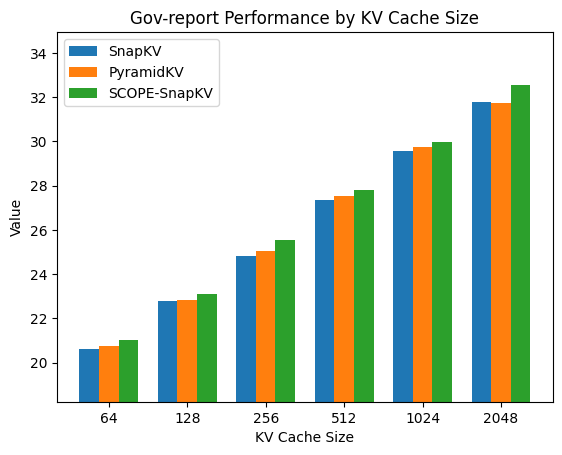

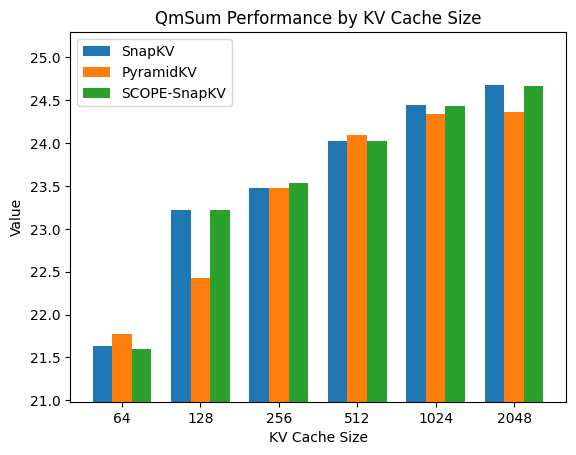

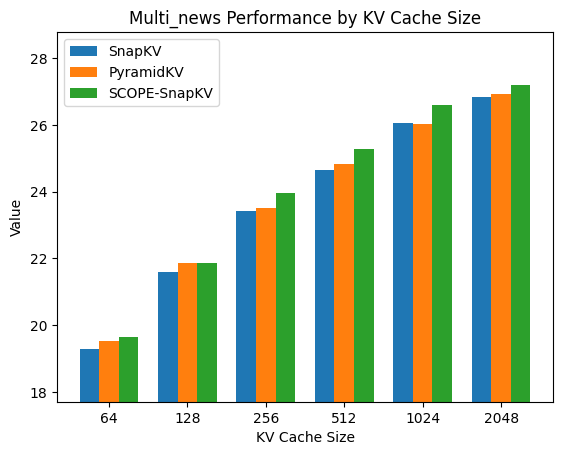

In [3]:
# Re-plot the first dataset with added FullKV reference line

import pandas as pd
import matplotlib.pyplot as plt

# Original data
data = {
    "KV cache size": [64, 64, 64, 128, 128, 128, 256, 256, 256, 512, 512, 512, 1024, 1024, 1024, 2048, 2048, 2048],
    "Method": ["SnapKV", "PyramidKV", "SCOPE-SnapKV"] * 6,
    "Gov-report": [20.62, 20.75, 21.04, 22.8, 22.85, 23.1, 24.81, 25.04, 25.53, 27.33, 27.55, 27.82, 29.56, 29.74, 29.96, 31.8, 31.73, 32.55],
    "QmSum": [21.63, 21.77, 21.6, 23.22, 22.43, 23.22, 23.48, 23.48, 23.53, 24.02, 24.1, 24.03, 24.45, 24.34, 24.43, 24.68, 24.36, 24.67],
    "Multi_news": [19.29, 19.52, 19.64, 21.58, 21.87, 21.85, 23.41, 23.52, 23.95, 24.65, 24.82, 25.27, 26.05, 26.02, 26.6, 26.84, 26.94, 27.2]
}

df = pd.DataFrame(data)

# Plotting for each dataset
datasets = ["Gov-report", "QmSum", "Multi_news"]
kv_sizes = sorted(df["KV cache size"].unique())
methods = df["Method"].unique()

# FullKV values for reference
fullkv_values = {
    "Gov-report": 35.22,
    "QmSum": 25.25,
    "Multi_news": 27.19
}

# Create bar charts with FullKV line
figs = []
for dataset in datasets:
    fig, ax = plt.subplots()
    width = 0.25
    for i, method in enumerate(methods):
        method_data = df[df["Method"] == method]
        ax.bar(
            [x + i*width for x in range(len(kv_sizes))],
            method_data[dataset],
            width=width,
            label=method
        )
    # Add FullKV reference line
    # ax.axhline(y=fullkv_values[dataset], linestyle='--', color='black', label='FullKV')

    ax.set_xticks([x + width for x in range(len(kv_sizes))])
    ax.set_xticklabels(kv_sizes)
    ax.set_xlabel("KV Cache Size")
    ax.set_ylabel("Value")
    ax.set_title(f"{dataset} Performance by KV Cache Size")
    ax.legend()

    # Adjust y-axis to enhance visual differences
    min_val = df[dataset].min()
    max_val = df[dataset].max()
    margin = (max_val - min_val) * 0.2
    ax.set_ylim(min_val - margin, max_val + margin)

    figs.append(fig)

plt.show()


## MiniCheck

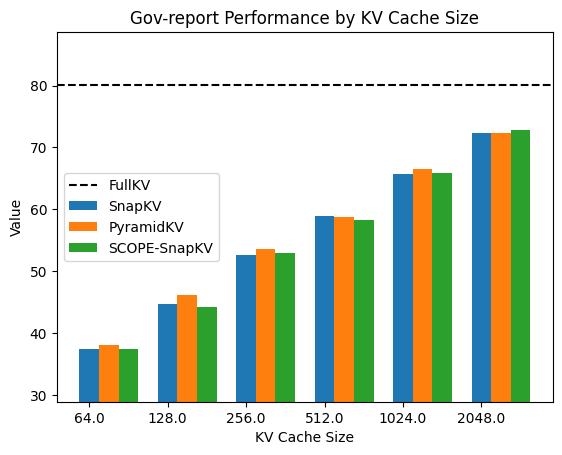

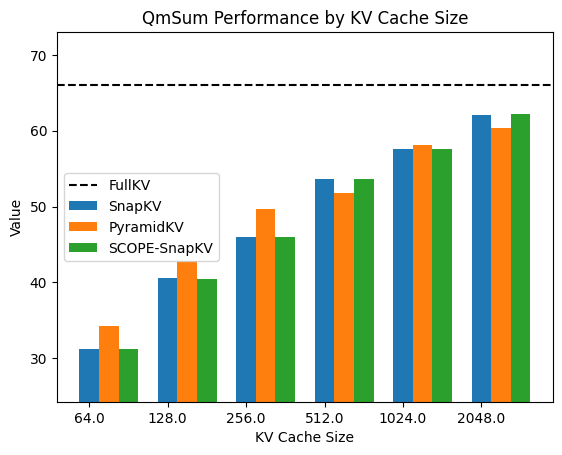

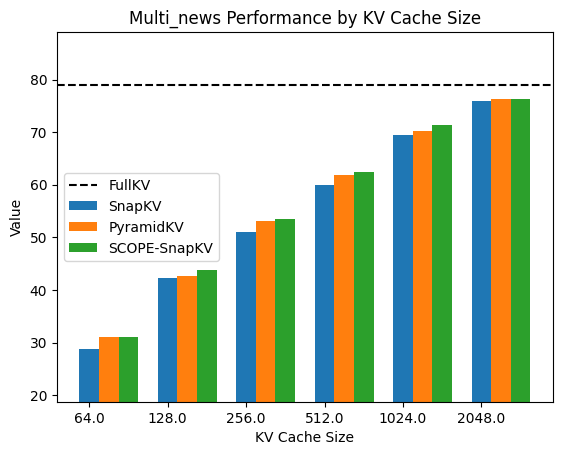

In [5]:
import numpy as np
# Create new dataset (third one) and remove Reference method
data3 = {
    "KV cache size": [None] + [64, 64, 64, 128, 128, 128, 256, 256, 256, 512, 512, 512, 1024, 1024, 1024, 2048, 2048, 2048],
    "Method": ["FullKV"] + ["SnapKV", "PyramidKV", "SCOPE-SnapKV"] * 6,
    "Gov-report": [80.11, 37.47, 38.03, 37.43, 44.74, 46.17, 44.22, 52.64, 53.56, 52.89, 58.84, 58.8, 58.35, 65.72, 66.52, 65.84, 72.35, 72.28, 72.75],
    "QmSum": [66.05, 31.22, 34.26, 31.21, 40.54, 42.75, 40.45, 45.92, 49.66, 45.92, 53.65, 51.85, 53.65, 57.56, 58.09, 57.59, 62.13, 60.34, 62.16],
    "Multi_news": [78.97, 28.8, 31.06, 30.98, 42.33, 42.75, 43.78, 51.04, 53.07, 53.44, 60.01, 61.77, 62.33, 69.46, 70.12, 71.33, 75.89, 76.32, 76.37]
}

df3 = pd.DataFrame(data3)

# Plotting for each dataset without Reference line, keeping FullKV
datasets3 = ["Gov-report", "QmSum", "Multi_news"]
kv_sizes3 = sorted(df3["KV cache size"].dropna().unique())
methods3 = df3["Method"].unique()

# Create bar charts
figs3 = []
for dataset in datasets3:
    fig, ax = plt.subplots()
    width = 0.25
    offset = np.array([x for x in range(len(kv_sizes3))])
    for i, method in enumerate(methods3):
        method_data = df3[df3["Method"] == method]
        if method_data["KV cache size"].isnull().all():
            # Plot FullKV as horizontal line
            val = method_data[dataset].values[0]
            ax.axhline(y=val, linestyle='--', color='black', label=method)
        else:
            values = method_data[dataset].values
            # Handle missing values by replacing with 0 and using alpha for visibility
            masked_values = [v if pd.notna(v) else 0 for v in values]
            alphas = [1.0 if pd.notna(v) else 0.2 for v in values]
            bars = ax.bar(
                offset + i*width,
                masked_values,
                width=width,
                label=method
            )
            # Adjust alpha for missing values
            for bar, alpha in zip(bars, alphas):
                bar.set_alpha(alpha)

    ax.set_xticks(offset + width)
    ax.set_xticklabels(kv_sizes3)
    ax.set_xlabel("KV Cache Size")
    ax.set_ylabel("Value")
    ax.set_title(f"{dataset} Performance by KV Cache Size")
    ax.legend()

    # Adjust y-axis to enhance visual differences
    min_val = df3[dataset].min(skipna=True)
    max_val = df3[dataset].max(skipna=True)
    margin = (max_val - min_val) * 0.2
    ax.set_ylim(min_val - margin, max_val + margin)

    figs3.append(fig)

plt.show()


## AlignScore

In [ ]:
# Create new dataset
data2 = {
    "KV cache size": [None] + [64, 64, 64, 128, 128, 128, 256, 256, 256, 512, 512, 512, 1024, 1024, 1024, 2048, 2048, 2048],
    "Method": ["FullKV"] + ["SnapKV", "PyramidKV", "SCOPE-SnapKV"] * 6,
    "Gov-report": [81.47, 42.31, 43, 42.15, 48.96, 48.22, 47.56, 53.01, 54.51, 52.58, 59.75, 59.43, 59.13, 64.62, 65.53, 65.3, 71.38, 71.46, 71.87],
    "QmSum": [69.07, 57.88, 59.49, 57.91, 63.77, 62.84, 63.66, 63.92, 62.95, 63.89, 65.32, 63.46, 65.28, 66.15, 65.76, 66.16, 66.88, 67.02, 67.15],
    "Multi_news": [77.79, 43.8, 44.62, 44.65, 49.9, 50.92, 50.85, 55.85, 57.95, 57.47, 62.97, 65.05, 64.43, 70.76, 71.36, 71.78, 75.42, 75.91, 75.5]
}

df2 = pd.DataFrame(data2)

# Plotting for each dataset with adjusted y-axis
datasets2 = ["Gov-report", "QmSum", "Multi_news"]
kv_sizes2 = sorted(df2["KV cache size"].dropna().unique())
methods2 = df2["Method"].unique()

import numpy as np

# Create bar charts
figs2 = []
for dataset in datasets2:
    fig, ax = plt.subplots()
    width = 0.25
    offset = np.array([x for x in range(len(kv_sizes2))])
    for i, method in enumerate(methods2):
        method_data = df2[df2["Method"] == method]
        if method_data["KV cache size"].isnull().all():
            # Plot reference/FullKV as horizontal lines
            val = method_data[dataset].values[0]
            ax.axhline(y=val, linestyle='--', label=method)
        else:
            ax.bar(
                offset + i*width,
                method_data[dataset].values,
                width=width,
                label=method
            )

    ax.set_xticks(offset + width)
    ax.set_xticklabels(kv_sizes2)
    ax.set_xlabel("KV Cache Size")
    ax.set_ylabel("Value")
    ax.set_title(f"{dataset} Performance by KV Cache Size")
    ax.legend()

    # Adjust y-axis to enhance visual differences
    min_val = df2[dataset].min()
    max_val = df2[dataset].max()
    margin = (max_val - min_val) * 0.2
    ax.set_ylim(min_val - margin, max_val + margin)

    figs2.append(fig)

plt.show()
